**v1.1 because i realized that i was including customersTracked but i shouldn't have been since that data is bad.**


(v1 from 27 april 2026, making an attempt at randomforest (to predict t90) to compare to the linear model in *regression5.ipynb*)

In [5]:
2+2

4

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

Cell 2 — Load data

In [7]:
# Load pre-built dataset
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"

event_df = pd.read_csv(data_path)

print(event_df.shape)
print(event_df.head())
print(event_df.columns.tolist())

(90, 11)
                            event_id          storm  CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275       12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333       12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333       12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333       12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333       12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0  12.601287      7.421799        67.413998      1009.864246   
1             0  27.279316     12.005697        92.750718       995.318712   
2             0  33.241034      9.333728       153.916280       982.833530   
3             0  25.291777     14.104932        89.230104       996.010565   
4             0  33.169058      9.553964       145.733609       976.919507   

   max_customers_tracked  county_pop  
0       

checks:

In [8]:
# Ensure correct types
event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

# Check for missing values
print(event_df.isna().sum())

# Check target distribution
print(event_df["t90"].describe())
print("Censored fraction:", event_df["t90_censored"].mean())

event_id                 0
storm                    0
CountyFIPS               0
t90                      0
t90_censored             0
max_gust                 0
mean_gust_7d             0
total_precip_7d          0
pressure_min_7d          0
max_customers_tracked    0
county_pop               0
dtype: int64
count     90.000000
mean     143.552083
std      104.756440
min        1.885185
25%       75.481588
50%      127.678903
75%      170.772337
max      551.473029
Name: t90, dtype: float64
Censored fraction: 0.0


Cell 3 — Basic cleaning + types

In [9]:
# obsolete; use filtered dataset

Cell 4 — Build event-level dataset

In [10]:
# obsolete; use filtered dataset

Cell 5 — Merge county population

In [11]:
# obsolete; use filtered dataset

Cell 6 — Define features and target

In [12]:
feature_cols = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    # "max_customers_tracked",
    "county_pop",
    "CountyFIPS"
]

target_col = "t90"
group_col = "storm"

X = event_df[feature_cols].copy()
y = event_df[target_col].copy()
groups = event_df[group_col].copy()

Cell 7 — Model pipeline

In [13]:
numeric_features = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    # "max_customers_tracked",
    "county_pop"
]

categorical_features = ["CountyFIPS"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

Cell 8 — Random Forest model

In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42
)

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", rf)
])

Cell 9 — Leave-one-storm-out CV

In [15]:
logo = LeaveOneGroupOut()

preds = np.full(len(X), np.nan)

fold_results = []

for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    storm_test = groups.iloc[test_idx].iloc[0]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    preds[test_idx] = y_pred

    fold_results.append({
        "fold": i,
        "storm": storm_test,
        "n": len(test_idx),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

fold_df = pd.DataFrame(fold_results)

print(fold_df)
print("\nMean MAE:", fold_df["mae"].mean())
print("Mean RMSE:", fold_df["rmse"].mean())

   fold          storm   n         mae        rmse
0     1  2017212N28275   1  130.358216  130.358216
1     2  2017242N16333  49  143.649739  154.287051
2     3  2018280N18273  14  169.221555  224.070706
3     4  2020256N25281   3   31.888555   34.646187
4     5  2021182N09317   1    6.669949    6.669949
5     6  2021222N14301   3   74.901196   84.273377
6     7  2022263N10313  19   46.171397   55.159955

Mean MAE: 86.12294408593483
Mean RMSE: 98.49506302140004


^ note this is not useful mae metrics since it's the folded


In [16]:
# Compare performance on non-censored only
mask = event_df["t90_censored"] == 0

print("\nNon-censored only:")
print("MAE:", mean_absolute_error(y[mask], preds[mask]))
print("RMSE:", np.sqrt(mean_squared_error(y[mask], preds[mask])))


Non-censored only:
MAE: 119.36214415802654
RMSE: 147.91447880531362


Cell 10 — Diagnostics

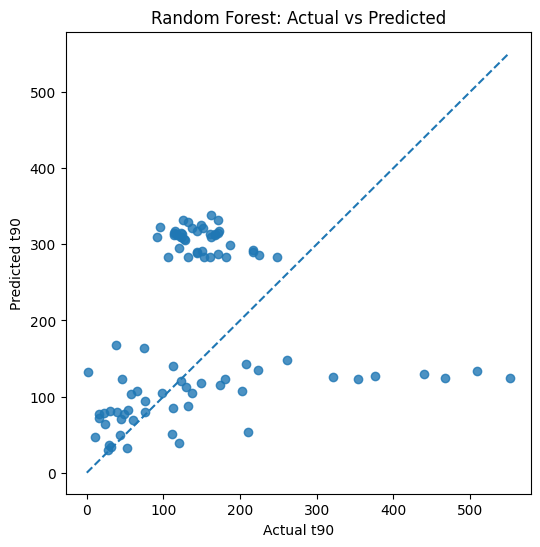

In [17]:
event_df["t90_pred"] = preds

plt.figure(figsize=(6,6))
plt.scatter(event_df["t90"], event_df["t90_pred"], alpha=0.8)
plt.plot([0, event_df["t90"].max()],
         [0, event_df["t90"].max()],
         linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Cell 11 — Feature importance

pressure_min_7d     0.368535
max_gust            0.274449
mean_gust_7d        0.235661
total_precip_7d     0.104432
county_pop          0.016832
CountyFIPS_12037    0.000090
CountyFIPS_12003    0.000000
CountyFIPS_12001    0.000000
CountyFIPS_12007    0.000000
CountyFIPS_12011    0.000000
CountyFIPS_12013    0.000000
CountyFIPS_12015    0.000000
CountyFIPS_12017    0.000000
CountyFIPS_12019    0.000000
CountyFIPS_12021    0.000000
dtype: float64


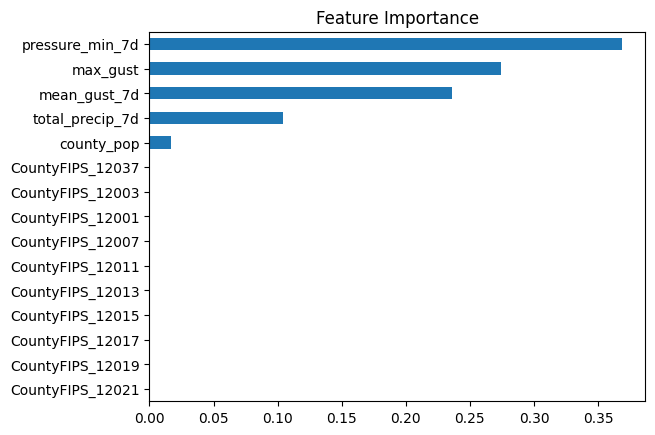

In [18]:
rf_model = model.named_steps["rf"]

# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(["CountyFIPS"])

feature_names = numeric_features + list(cat_names)

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp.head(15))

feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

Now, **without CountyFIPS**:

In [19]:
feature_cols_nocounty = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    # "max_customers_tracked",
    "county_pop"
]

X_nc = event_df[feature_cols_nocounty].copy()
y_nc = event_df["t90"].copy()
groups_nc = event_df["storm"].copy()

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipe_nc = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_nc = ColumnTransformer([
    ("num", numeric_pipe_nc, feature_cols_nocounty)
])

In [21]:
rf_nc = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42
)

model_nc = Pipeline([
    ("preprocess", preprocess_nc),
    ("rf", rf_nc)
])

In [22]:
logo = LeaveOneGroupOut()

preds_nc = np.full(len(X_nc), np.nan)

fold_results_nc = []

for i, (train_idx, test_idx) in enumerate(logo.split(X_nc, y_nc, groups_nc), start=1):
    X_train, X_test = X_nc.iloc[train_idx], X_nc.iloc[test_idx]
    y_train, y_test = y_nc.iloc[train_idx], y_nc.iloc[test_idx]
    storm_test = groups_nc.iloc[test_idx].iloc[0]

    model_nc.fit(X_train, y_train)
    y_pred = model_nc.predict(X_test)

    preds_nc[test_idx] = y_pred

    fold_results_nc.append({
        "fold": i,
        "storm": storm_test,
        "n": len(test_idx),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    })

fold_df_nc = pd.DataFrame(fold_results_nc)

print(fold_df_nc)
print("\nMean MAE (no county):", fold_df_nc["mae"].mean())
print("Mean RMSE (no county):", fold_df_nc["rmse"].mean())
print("but ignore this since it's fold-average. ")

   fold          storm   n         mae        rmse
0     1  2017212N28275   1  129.058034  129.058034
1     2  2017242N16333  49  142.830607  153.354792
2     3  2018280N18273  14  169.145476  223.753321
3     4  2020256N25281   3   31.503401   34.310886
4     5  2021182N09317   1    6.458228    6.458228
5     6  2021222N14301   3   73.582164   82.755665
6     7  2022263N10313  19   46.228861   55.199812

Mean MAE (no county): 85.54382433483877
Mean RMSE (no county): 97.84153379970179
but ignore this since it's fold-average. 


In [23]:
print("\n--- Correct (global) metrics ---")
print("Global MAE (no county):", mean_absolute_error(y_nc, preds_nc))
print("Global RMSE (no county):", np.sqrt(mean_squared_error(y_nc, preds_nc)))


--- Correct (global) metrics ---
Global MAE (no county): 118.8428633357805
Global RMSE (no county): 147.26970167757005


^ note this is not useful mae metrics since it's the folded


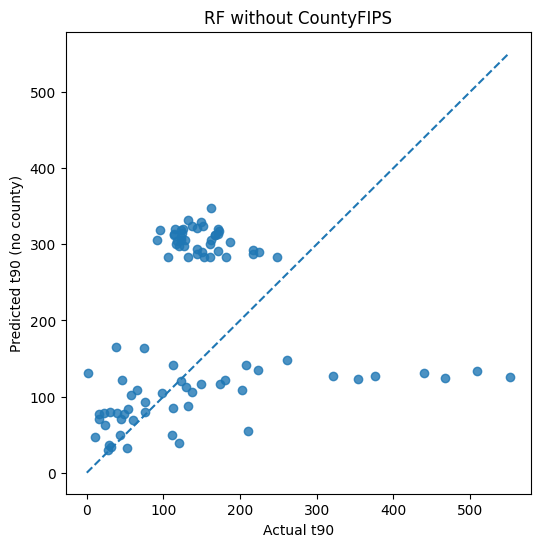

In [24]:
event_df["t90_pred_no_county"] = preds_nc

plt.figure(figsize=(6,6))
plt.scatter(event_df["t90"], event_df["t90_pred_no_county"], alpha=0.8)

m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90 (no county)")
plt.title("RF without CountyFIPS")
plt.show()

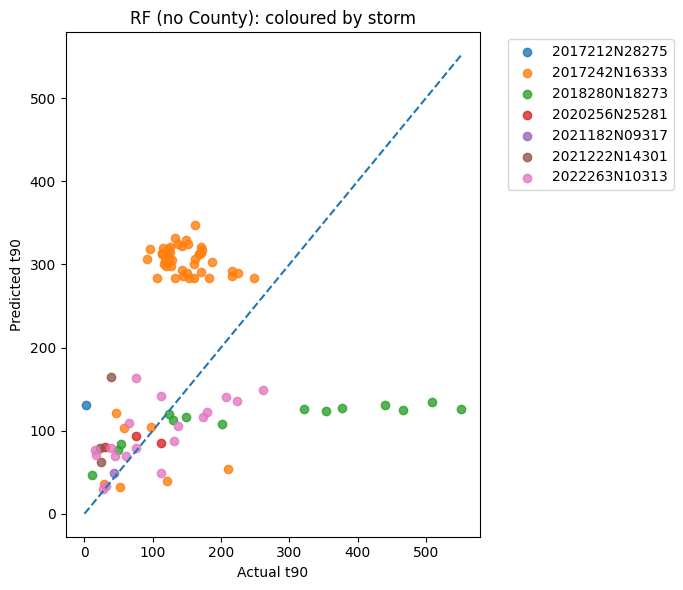

In [25]:
import matplotlib.pyplot as plt

# Ensure predictions exist
# (from your RF without county run)
# event_df["t90_pred_no_county"] should already be present

plt.figure(figsize=(7,6))

storms = event_df["storm"].unique()

for storm in storms:
    subset = event_df[event_df["storm"] == storm]
    plt.scatter(
        subset["t90"],
        subset["t90_pred_no_county"],
        label=storm,
        alpha=0.8
    )

# Diagonal line
m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("RF (no County): coloured by storm")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

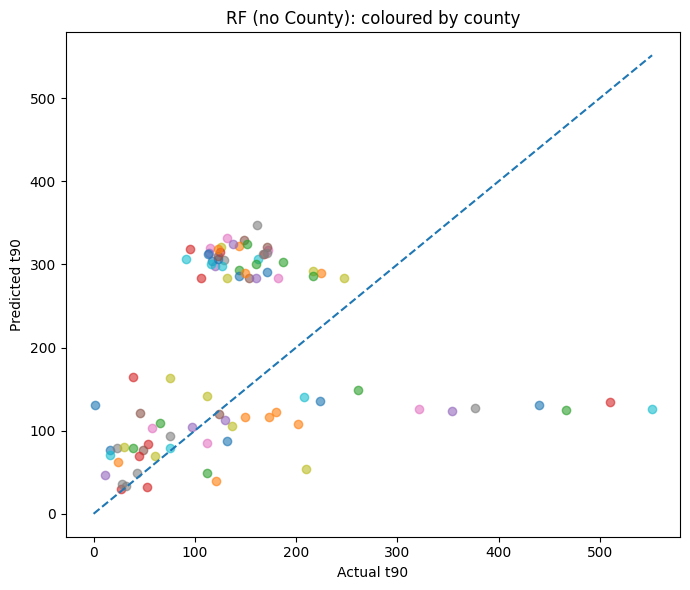

In [26]:
plt.figure(figsize=(7,6))

counties = event_df["CountyFIPS"].unique()

for county in counties:
    subset = event_df[event_df["CountyFIPS"] == county]
    plt.scatter(
        subset["t90"],
        subset["t90_pred_no_county"],
        alpha=0.6
    )

# Diagonal
m = event_df["t90"].max()
plt.plot([0, m], [0, m], linestyle="--")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("RF (no County): coloured by county")

plt.tight_layout()
plt.show()

^ no real trend

pressure_min_7d    0.371087
max_gust           0.248345
mean_gust_7d       0.232065
total_precip_7d    0.131728
county_pop         0.016775
dtype: float64


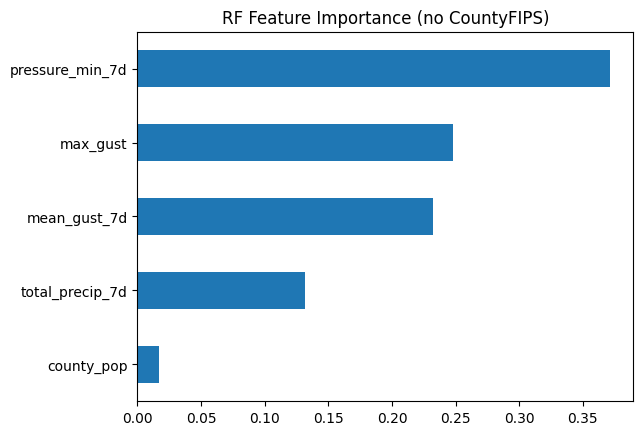

In [27]:
# -----------------------
# Feature importance (no CountyFIPS)
# -----------------------
rf_model_nc = model_nc.named_steps["rf"]

importances_nc = rf_model_nc.feature_importances_

feat_imp_nc = pd.Series(importances_nc, index=feature_cols_nocounty).sort_values(ascending=False)

print(feat_imp_nc)

feat_imp_nc.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RF Feature Importance (no CountyFIPS)")
plt.show()

In [28]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


SHAP; note this is meant for model already fully trained, using full dataset, not the folded dataset, so take with a grain of salt.

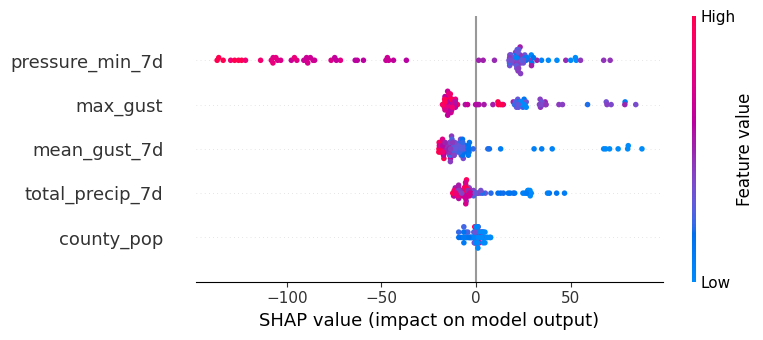

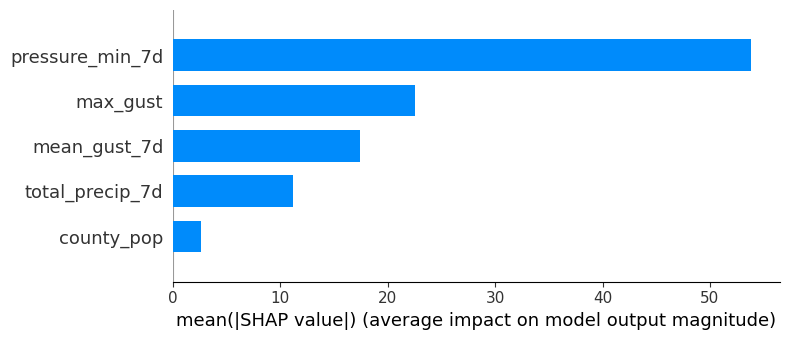

In [29]:
import shap

# Extract trained RF model
rf_model_nc = model_nc.named_steps["rf"]

# Preprocessed data
X_proc = model_nc.named_steps["preprocess"].transform(X_nc)

# SHAP explainer
explainer = shap.TreeExplainer(rf_model_nc)

# Compute SHAP values
shap_values = explainer.shap_values(X_proc)

shap.summary_plot(
    shap_values,
    X_proc,
    feature_names=feature_cols_nocounty
)

shap.summary_plot(
    shap_values,
    X_proc,
    feature_names=feature_cols_nocounty,
    plot_type="bar"
)

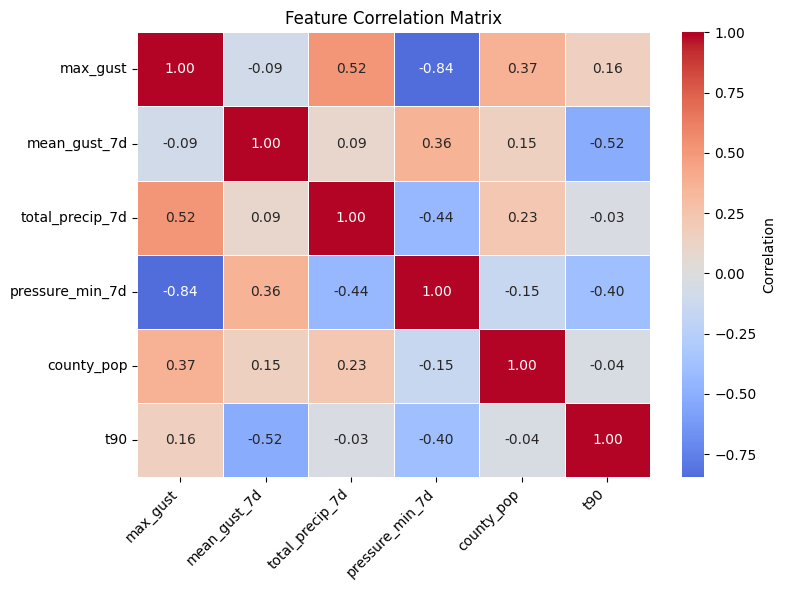

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# Correlation matrix
# -----------------------
corr_cols = feature_cols_nocounty + ["t90"]

corr = event_df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()